In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

'''
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
'''

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

"\nimport os\nfor dirname, _, filenames in os.walk('/kaggle/input'):\n    for filename in filenames:\n        print(os.path.join(dirname, filename))\n"

# Importing necessary libraries

In [13]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns


# SCALED DOT-PRODUCT ATTENTION

In [18]:
# SCALED DOT-PRODUCT ATTENTION FUNCTION

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Scaled Dot-Product Attention: Attention(Q,K,V) = softmax(QK^T/√dk)V
    
    Args:
        Q: Query [B, T, dk] - What we're looking for
        K: Key [B, T, dk] - What we might find  
        V: Value [B, T, dv] - What we actually use
        mask: [B, T, T] - Optional attention mask
    
    Returns:
        output: [B, T, dv] - Context-aware representations
        weights: [B, T, T] - Attention distribution
    """
    B, T, dk = Q.shape  # Extract dimensions: Batch, Time(Sequence), Key dim
    
    # STEP 1: Raw dot products QK^T
    # Q[B,T,dk] * K^T[B,dk,T] -> scores[B,T,T]
    scores = torch.matmul(Q, K.transpose(-2, -1))
    
    print("Raw dot products (before scaling):")
    print(f"  Min: {scores.min():.3f}, Max: {scores.max():.3f}, Mean: {scores.mean():.3f}")
    
    # STEP 2: Scale by √dk (CRITICAL for stability)
    # Without scaling: large dk → huge scores → softmax → one-hot (bad!)
    scores_scaled = scores / math.sqrt(dk)
    
    print("\nScaled scores (after /√dk):")
    print(f"  Min: {scores_scaled.min():.3f}, Max: {scores_scaled.max():.3f}")
    
    # STEP 3: Applying mask (set invalid positions to -inf)
    if mask is not None:
        # masked_fill: positions where mask==0 become -1e9 → softmax→0
        scores_scaled = scores_scaled.masked_fill(mask == 0, -1e9)
    
    # STEP 4: Softmax across key dimension → attention weights
    attention_weights = F.softmax(scores_scaled, dim=-1)
    
    # STEP 5: Weighted sum: attention_weights @ V
    # [B,T,T] @ [B,T,dv] -> [B,T,dv]
    output = torch.matmul(attention_weights, V)
    
    # Verifying weights sum to 1 across last dimension
    print(f"\nAttention weights range: [{attention_weights.min():.3f}, {attention_weights.max():.3f}]")
    # print(f"Weights sum to 1: {torch.allclose(attention_weights.sum(dim=-1), 1.0, atol=1e-5)}")
    print(f"Weights sum to 1: {torch.allclose(attention_weights.sum(dim=-1), torch.ones_like(attention_weights.sum(dim=-1)), atol=1e-5)}")
    
    return output, attention_weights



# TEST SETUP

In [19]:
# TEST SETUP

print("-"*60)
print("SCALED DOT-PRODUCT ATTENTION IMPLEMENTATION")
print("-"*60)

# Creating reproducible random data
torch.manual_seed(42)
B, T, dk, dv = 2, 8, 64, 64  # Batch=2, Seq=8, dk=64, dv=64

# Random Q,K,V with larger variance to demonstrate scaling effect
Q = torch.randn(B, T, dk) * 2
K = torch.randn(B, T, dk) * 2  
V = torch.randn(B, T, dv)

print(f"Input shapes - Q:{Q.shape}, K:{K.shape}, V:{V.shape}")
print(f"Scaling factor: √dk = {math.sqrt(dk):.1f}")




------------------------------------------------------------
SCALED DOT-PRODUCT ATTENTION IMPLEMENTATION
------------------------------------------------------------
Input shapes - Q:torch.Size([2, 8, 64]), K:torch.Size([2, 8, 64]), V:torch.Size([2, 8, 64])
Scaling factor: √dk = 8.0


# TESTS

In [29]:
# TEST 1 - NO MASK

print("\n" + "="*50)
print("TEST 1: NO MASK")
print("="*50)
output1, attn1 = scaled_dot_product_attention(Q, K, V)
print(f"Output shape: {output1.shape}")
print(f"Attention shape: {attn1.shape}")

# printing ACTUAL MATRICES
print("\nATTENTION WEIGHT MATRIX [B=0, T=8, T=8] (first sequence):")
print(attn1[0].detach().numpy().round(3)) # First sequence full matrix

print("\nOUTPUT VECTORS [B=0, T=8, dv=64] (first sequence, first 5 dims):")
print(output1[0, :, :5].detach().numpy().round(3)) # First sequence, first 5 dims


TEST 1: NO MASK
Raw dot products (before scaling):
  Min: -82.207, Max: 87.793, Mean: -1.196

Scaled scores (after /√dk):
  Min: -10.276, Max: 10.974

Attention weights range: [0.000, 0.999]
Weights sum to 1: True
Output shape: torch.Size([2, 8, 64])
Attention shape: torch.Size([2, 8, 8])

ATTENTION WEIGHT MATRIX (first sequence):
[[0.001 0.001 0.036 0.01  0.939 0.002 0.001 0.009]
 [0.    0.    0.013 0.978 0.    0.    0.    0.009]
 [0.    0.002 0.003 0.008 0.008 0.    0.002 0.978]
 [0.    0.    0.    0.999 0.    0.    0.    0.   ]
 [0.    0.    0.    0.998 0.    0.001 0.001 0.   ]
 [0.001 0.    0.002 0.905 0.038 0.    0.054 0.   ]
 [0.    0.002 0.189 0.035 0.    0.006 0.    0.769]
 [0.013 0.    0.001 0.    0.    0.936 0.002 0.048]]

OUTPUT VECTORS (first sequence, first 5 dims):
[[-0.989 -0.18  -0.432  0.36   0.325]
 [-0.065 -0.927  1.417  0.128 -0.186]
 [ 1.554  0.682  1.872 -1.083 -2.161]
 [-0.062 -0.942  1.431  0.132 -0.183]
 [-0.061 -0.944  1.428  0.133 -0.182]
 [-0.117 -0.949  1.

In [30]:
# TEST 2 - CAUSAL MASK

print("\n" + "="*50)
print("TEST 2: CAUSAL MASK (future cannot attend to past)")
print("="*50)

# Create lower triangular mask for autoregressive generation
# 1s on/above diagonal, 0s below = "only attend to previous positions"
causal_mask = torch.tril(torch.ones(T, T)).unsqueeze(0)  # [1, T, T]

output2, attn2 = scaled_dot_product_attention(Q, K, V, causal_mask)
print(f"Masked output shape: {output2.shape}")


print("\nMASKED ATTENTION MATRIX [B=0]:")
print(attn2[0].detach().numpy().round(3))

print("\nMASKED OUTPUT VECTORS [B=0, first 5 dims]:")
print(output2[0, :, :5].detach().numpy().round(3))


TEST 2: CAUSAL MASK (future cannot attend to past)
Raw dot products (before scaling):
  Min: -82.207, Max: 87.793, Mean: -1.196

Scaled scores (after /√dk):
  Min: -10.276, Max: 10.974

Attention weights range: [0.000, 1.000]
Weights sum to 1: True
Masked output shape: torch.Size([2, 8, 64])

MASKED ATTENTION MATRIX [B=0]:
[[1.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.054 0.946 0.    0.    0.    0.    0.    0.   ]
 [0.001 0.406 0.593 0.    0.    0.    0.    0.   ]
 [0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.001 0.    0.002 0.958 0.04  0.    0.    0.   ]
 [0.    0.007 0.817 0.152 0.    0.024 0.    0.   ]
 [0.013 0.    0.001 0.    0.    0.936 0.002 0.048]]

MASKED OUTPUT VECTORS [B=0, first 5 dims]:
[[-0.6   -0.058  0.297  1.633 -1.495]
 [-0.538 -1.333  1.806  1.374 -0.883]
 [-1.067 -1.09   0.774  0.928  0.165]
 [-0.062 -0.942  1.431  0.132 -0.183]
 [-0.061 -0.942  1.432  0.132 -0.182]
 [-0.102 -0.91   1.352  0.143 -

# VISUALIZATIONS


--------------------------------------------------
ATTENTION VISUALIZATION (First sequence)
--------------------------------------------------


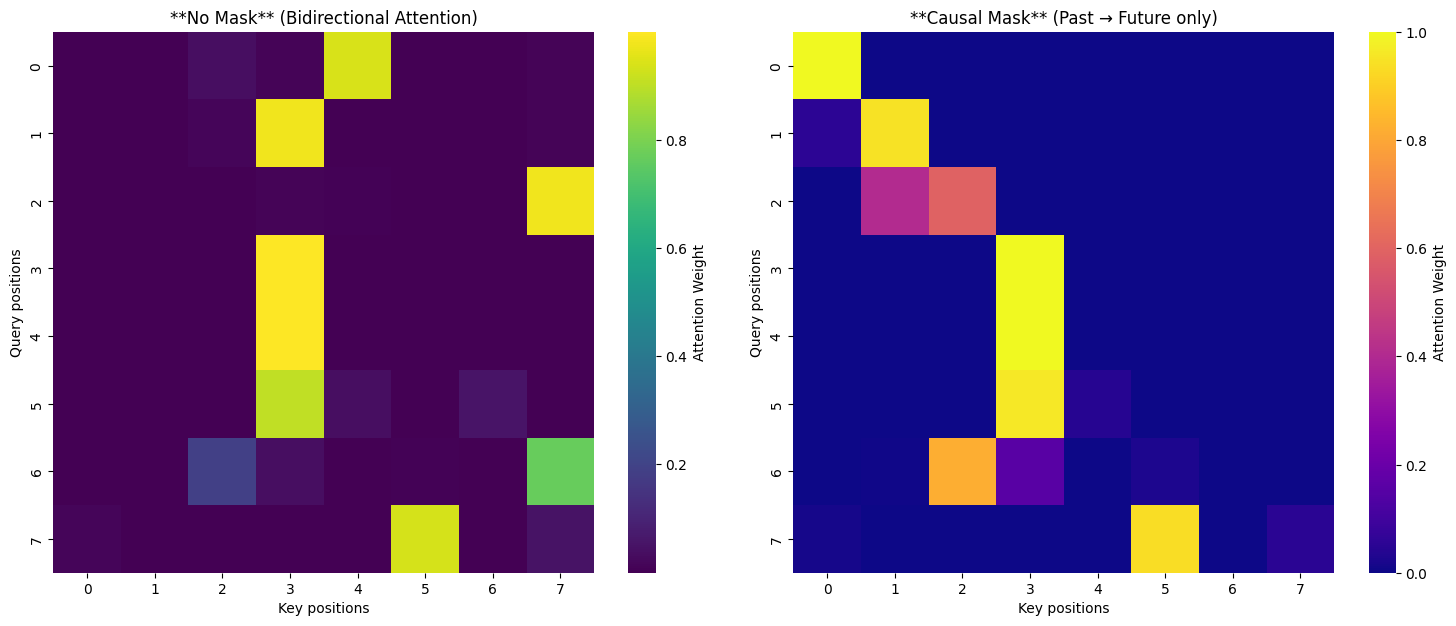

In [26]:
# VISUALIZATIONS

print("\n" + "-"*50)
print("ATTENTION VISUALIZATION (First sequence)")
print("-"*50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot unmasked attention (full bidirectional)
sns.heatmap(
    attn1[0].detach().numpy(),
    cmap="viridis",
    ax=ax1,
    cbar_kws={'label': 'Attention Weight'},
    square=True
)
ax1.set_title("**No Mask** (Bidirectional Attention)")
ax1.set_xlabel("Key positions")
ax1.set_ylabel("Query positions")

# Plot masked attention (causal/autoregressive)
sns.heatmap(
    attn2[0].detach().numpy(),
    cmap="plasma", 
    ax=ax2,
    cbar_kws={'label': 'Attention Weight'},
    square=True
)
ax2.set_title("**Causal Mask** (Past → Future only)")
ax2.set_xlabel("Key positions")
ax2.set_ylabel("Query positions")

plt.tight_layout()
plt.show()

In [27]:
# SOFTMAX STABILITY CHECK

print("\n" + "-"*60)
print("SOFTMAX STABILITY CHECK")
print("-"*60)

# Extreme scores to demonstrate why scaling matters
extreme_raw = torch.tensor([[10.0, 9.0, 8.0, 7.0]])
extreme_scaled = extreme_raw / math.sqrt(4)  # √dk where dk=4

print("Raw scores (NO scaling):      ", extreme_raw.numpy())
print("Softmax(raw):                 ", F.softmax(extreme_raw, dim=-1).numpy())
print("\nScaled scores (/√dk):         ", extreme_scaled.numpy())
print("Softmax(scaled):              ", F.softmax(extreme_scaled, dim=-1).numpy())

print("\n" + "="*60)
print("SCALING PREVENTS SOFTMAX COLLAPSE!")
print("Without scaling → one-hot distribution")
print("With scaling → smooth probability distribution")
print("="*60)


------------------------------------------------------------
SOFTMAX STABILITY CHECK
------------------------------------------------------------
Raw scores (NO scaling):       [[10.  9.  8.  7.]]
Softmax(raw):                  [[0.6439143  0.23688284 0.08714432 0.0320586 ]]

Scaled scores (/√dk):          [[5.  4.5 4.  3.5]]
Softmax(scaled):               [[0.45505422 0.27600434 0.1674051  0.10153633]]

SCALING PREVENTS SOFTMAX COLLAPSE!
Without scaling → one-hot distribution
With scaling → smooth probability distribution
